In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

##### Carga del dataset

In [2]:
df = pd.read_csv('../../../data/breast_cancer.csv')
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


##### Exploracion y preprocesamiento de datos


In [13]:
numeric_columns = df.columns.drop(['id', 'diagnosis'])
df[numeric_columns] = df[numeric_columns].astype(float)

# Convertir diagnóstico a valores numéricos (M=1, B=0)
df['diagnosis'] = (df['diagnosis'] == 'M').astype(int)

# Verificar valores nulos
print("Valores nulos en el dataset:")
print(df.isnull().sum())

# Separar características y etiquetas
X = df[numeric_columns]
y = df['diagnosis']

# Normalización de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)



Valores nulos en el dataset:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_di

c:\Users\Ivan\miniconda3\envs\deep_learning\lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\Ivan\miniconda3\envs\deep_learning\lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\Ivan\miniconda3\envs\deep_learning\lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Implementacion MLP

In [14]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


##### Entrenamiento del modelo

Epoch 1/50
12/12 [==============================] - 1s 24ms/step - loss: 0.6906 - accuracy: 1.0000 - val_loss: 0.6872 - val_accuracy: 1.0000
Epoch 2/50
12/12 [==============================] - 0s 4ms/step - loss: 0.6846 - accuracy: 1.0000 - val_loss: 0.6812 - val_accuracy: 1.0000
Epoch 3/50
12/12 [==============================] - 0s 4ms/step - loss: 0.6787 - accuracy: 1.0000 - val_loss: 0.6753 - val_accuracy: 1.0000
Epoch 4/50
12/12 [==============================] - 0s 4ms/step - loss: 0.6728 - accuracy: 1.0000 - val_loss: 0.6695 - val_accuracy: 1.0000
Epoch 5/50
12/12 [==============================] - 0s 4ms/step - loss: 0.6670 - accuracy: 1.0000 - val_loss: 0.6637 - val_accuracy: 1.0000
Epoch 6/50
12/12 [==============================] - 0s 3ms/step - loss: 0.6612 - accuracy: 1.0000 - val_loss: 0.6580 - val_accuracy: 1.0000
Epoch 7/50
12/12 [==============================] - 0s 4ms/step - loss: 0.6555 - accuracy: 1.0000 - val_loss: 0.6523 - val_accuracy: 1.0000
Epoch 8/50
12/12 [=

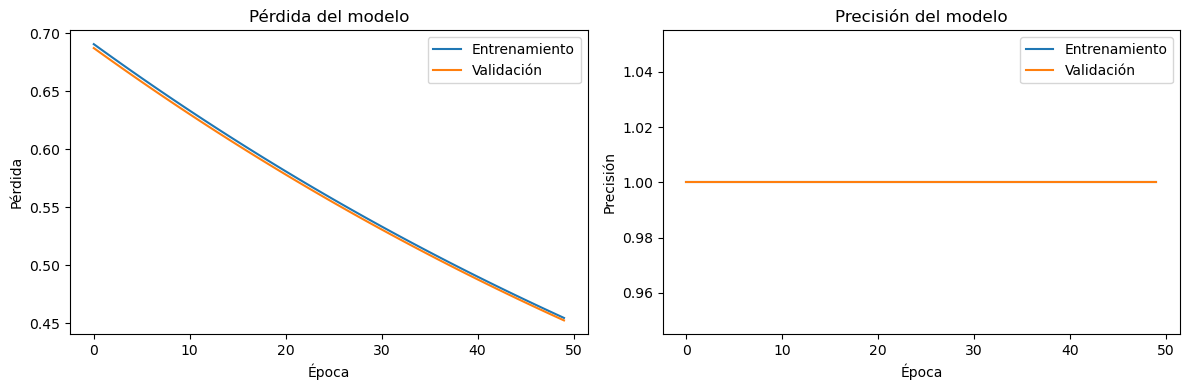

In [15]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Visualización de las curvas de aprendizaje
plt.figure(figsize=(12, 4))

# Gráfica de pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

# Gráfica de precisión
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.tight_layout()
plt.show()

##### Evaluacion del modelo

4/4 [==============================] - 0s 2ms/step


c:\Users\Ivan\miniconda3\envs\deep_learning\lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


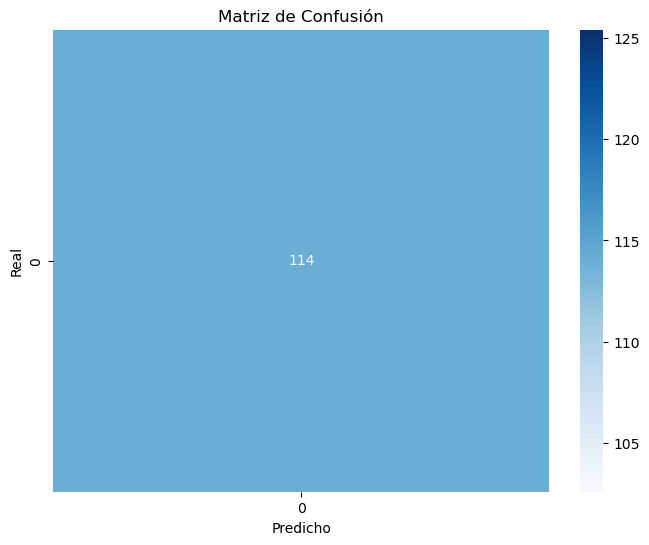


Informe de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       114

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



In [16]:
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# Métricas de evaluación
print("\nInforme de clasificación:")
print(classification_report(y_test, y_pred_classes))

##### Conclusiones

¿Es adecuada la red MLP básica?

La MLP puede ser adecuada, pero es posible que el rendimiento sea limitado si el dataset tiene características muy correlacionadas o complejas. La precisión podría ser alta, pero revisar la matriz de confusión y las métricas como F1-score es crucial.
¿Cómo mejorarla?

Ajuste de hiperparámetros: Cambiar el número de capas, neuronas, optimizador o tasa de aprendizaje.
Ingeniería de características: Reducir dimensiones con técnicas como PCA o eliminar colinealidades entre características.
Aumentar datos: Considerar técnicas de aumento de datos (si aplica).